In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_excel('cgpaPRED.xls')

In [51]:
df.head()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


In [52]:
df.describe()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
count,379.000000,379.000000,379.000000,379.000000,379.000000
mean,5.908707,6.015858,6.103852,6.167546,6.050765
std,3.147572,3.139440,3.078922,3.131259,3.091451
min,0.100000,0.100000,0.130000,0.120000,0.140000
25%,4.080000,4.275000,4.870000,4.990000,4.290000
50%,7.150000,7.240000,7.500000,7.450000,7.420000
75%,8.190000,8.320000,8.225000,8.440000,8.220000
max,9.800000,9.880000,9.730000,9.880000,9.640000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB


In [54]:
df.isnull()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
374,False,False,False,False,False
375,False,False,False,False,False
376,False,False,False,False,False
377,False,False,False,False,False


In [55]:
df.isnull().sum()

SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64

we found there is no null values so we proceed for train_test split


Train_Test_Split

In [56]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [57]:
x.head()

,SEM 1,SEM 2,SEM 3,SEM 4
0,6.60,7.60,6.90,7.22
1,7.77,7.22,7.00,7.90
2,6.90,6.00,7.12,7.54
3,5.50,6.60,6.70,6.50
4,7.20,6.00,7.21,7.70


In [58]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

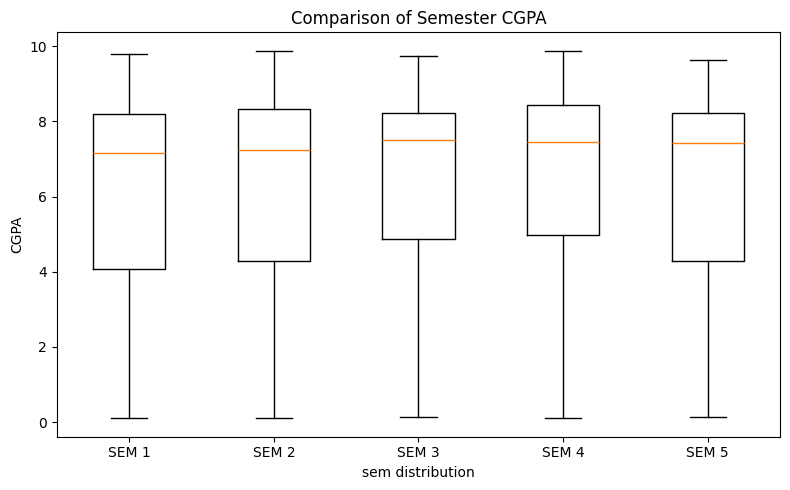

In [59]:

plt.figure(figsize=(8,5))

plt.boxplot([
    df["SEM 1"],
    df["SEM 2"],
    df["SEM 3"],
    df["SEM 4"],
    df["SEM 5"]
])

plt.xticks([1,2,3,4,5], ["SEM 1","SEM 2","SEM 3","SEM 4","SEM 5"])
plt.xlabel("sem distribution")
plt.ylabel("CGPA")
plt.title("Comparison of Semester CGPA")
plt.tight_layout()

plt.show()

cooreletion matrix to find reletion ship between features with target 

<Axes: >

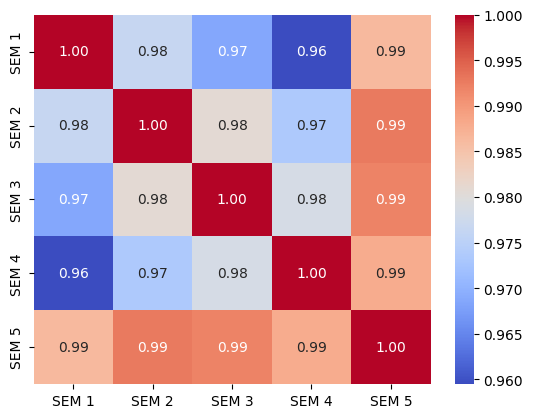

In [60]:
corr_matrix = df.corr()

plt.Figure(figsize=((15,10)))

sns.heatmap(
    corr_matrix,
    annot= True,
    fmt = ".2f",
    cmap="coolwarm"
)

In [61]:
df.corr()["SEM 5"].sort_values(ascending= False)

SEM 5    1.000000
SEM 2    0.992863
SEM 3    0.992036
SEM 4    0.987919
SEM 1    0.986322
Name: SEM 5, dtype: float64

Linear regression

In [62]:
x_1 = df[["SEM 2"]]
y_1  = df["SEM 5"]

In [63]:
x_1.head()


,SEM 2
0,7.60
1,7.22
2,6.00
3,6.60
4,6.00


In [64]:

y_1.head()

0    7.08
1    7.47
2    6.89
3    6.33
4    7.03
Name: SEM 5, dtype: float64

In [65]:
x_1_train,x_1_test,y_1_train,y_1_test = train_test_split(x_1,y_1,test_size=0.2,random_state=42)

scalling(standarddization)

In [66]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_1_train,y_1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Evaluation metrics for Linear regression

In [81]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
y_pred = model.predict(x_1_test)
mae = mean_absolute_error(y_1_test,y_pred)
mse = mean_squared_error(y_1_test,y_pred)
rmse = root_mean_squared_error(y_1_test,y_pred)
r2 = r2_score(y_1_test,y_pred)
print("MAE = ",mae)
print("MSE = ",mse)
print("RMSE = ",rmse)
print("r2 = ",r2)

MAE =  0.24539275272591385
MSE =  0.11749088625729902
RMSE =  0.34276943600224774
r2 =  0.9887037961166778


MLR(multiple linear regression)

In [68]:
x_2 = df.iloc[:,:-1]
y_2 = df.iloc[:,-1]

In [69]:
x_2.head()


,SEM 1,SEM 2,SEM 3,SEM 4
0,6.60,7.60,6.90,7.22
1,7.77,7.22,7.00,7.90
2,6.90,6.00,7.12,7.54
3,5.50,6.60,6.70,6.50
4,7.20,6.00,7.21,7.70


In [70]:
y_2.head()

0    7.08
1    7.47
2    6.89
3    6.33
4    7.03
Name: SEM 5, dtype: float64

In [71]:
x_2_train,x_2_test,y_2_train,y_2_test = train_test_split(x_2,y_2,test_size=0.2,random_state=42)

In [72]:
model_1 = LinearRegression()
model_1.fit(x_2_train,y_2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
y_1_pred = model_1.predict(x_2_test)
mae_1 = mean_absolute_error(y_2_test,y_1_pred)
mse_1 = mean_squared_error(y_2_test,y_1_pred)
rmse_1 = root_mean_squared_error(y_2_test,y_1_pred)
r2_1 = r2_score(y_2_test,y_1_pred)
print("MAE = ",mae_1)
print("MSE = ",mse_1)
print("RMSE = ",rmse_1)
print("r2 = ",r2_1)

MAE =  0.0023391696650218933
MSE =  7.162756055513766e-06
RMSE =  0.0026763325756553064
r2 =  0.9999993113342205


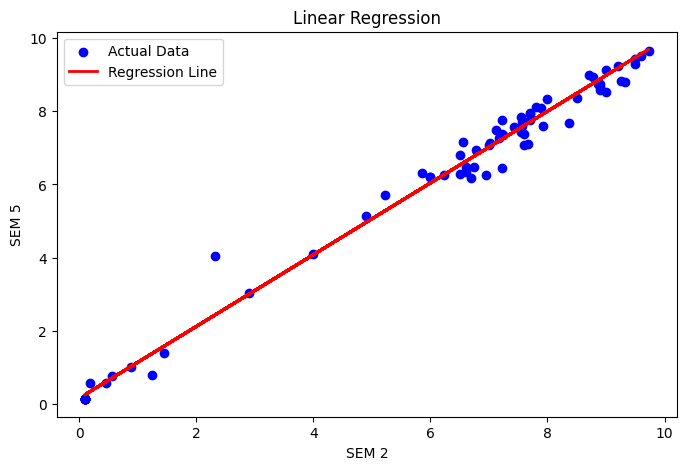

In [76]:
plt.figure(figsize=(8,5))
plt.scatter(x_1_test, y_1_test, color="blue", label="Actual Data")

# Regression Line
plt.plot(x_1_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.title("Linear Regression")
plt.xlabel("SEM 2")
plt.ylabel("SEM 5")
plt.legend()

plt.show()

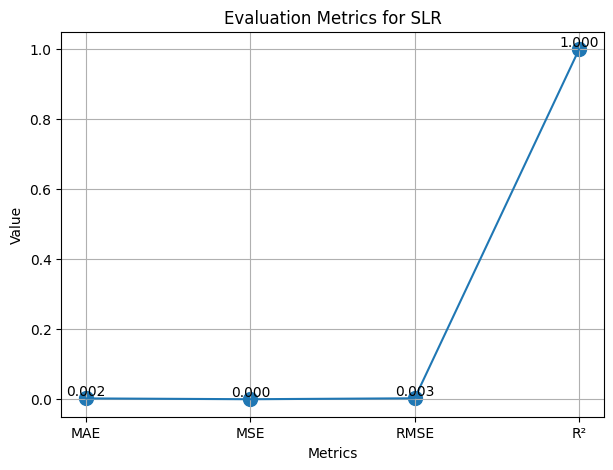

In [ ]:


# Evaluation metrics
metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae, mse, rmse, r2]

plt.figure(figsize=(7,5))

plt.scatter(metrics, values, s=100)

# Join the points 
plt.plot(metrics, values)

# Display values
for i in range(len(metrics)):
    plt.text(metrics[i], values[i], f"{values[i]:.3f}", ha="center", va="bottom")

plt.title("Evaluation Metrics for SLR")
plt.xlabel("Metrics")
plt.ylabel("Value")

plt.grid(True)
plt.show()

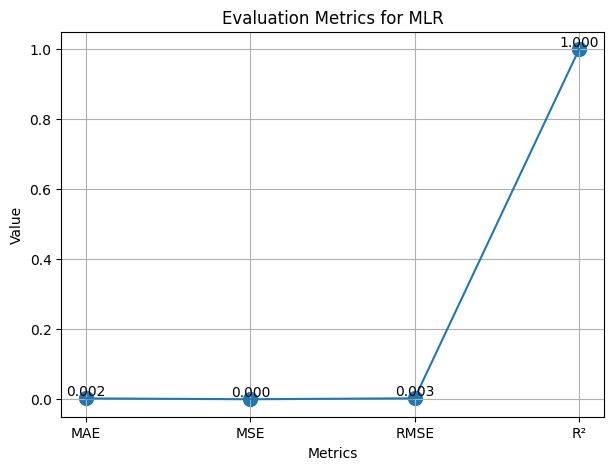

In [ ]:
metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae_1, mse_1, rmse_1, r2_1]

plt.figure(figsize=(7,5))

plt.scatter(metrics, values, s=100)

# Join the points 
plt.plot(metrics, values)

# Display values
for i in range(len(metrics)):
    plt.text(metrics[i], values[i], f"{values[i]:.3f}", ha="center", va="bottom")

plt.title("Evaluation Metrics for MLR")
plt.xlabel("Metrics")
plt.ylabel("Value")

plt.grid(True)
plt.show()